In [1]:
import torch
import torch.nn as nn
import torch.utils
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

import wandb
import random

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

WANDB_PROJECT = "dl-assignment-vae"  # change if you want
RUN_NAME = None                     # or e.g. f"vae_dim3={dim3}_seed={seed}"

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [3]:
class FF(nn.Module):
    def __init__(self, dim1, dim2, dim3):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(in_features=dim1, out_features=dim2),
            nn.ReLU(),
            nn.Linear(in_features=dim2, out_features=dim3)
        )

    def forward(self, input):
        return self.main(input)

In [4]:
class VAE(nn.Module):
    def __init__(self, dim1, dim2, dim3):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(dim1, dim2)
        self.fc21 = nn.Linear(dim2, dim3)  # Mean
        self.fc22 = nn.Linear(dim2, dim3)  # Variance
        self.fc3 = nn.Linear(dim3, dim2)
        self.fc4 = nn.Linear(dim2, dim1)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [5]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 28*28), reduction="sum")
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD, BCE, KLD


In [6]:
def train(data_loader, model, optimizer, epochs=20):
    model.to(device)
    model.train()

    losses = []
    global_step = 0

    for epoch in range(epochs):
        for i, (x, _) in enumerate(data_loader):
            x = x.to(device)
            optimizer.zero_grad()

            recon_batch, mu, logvar = model(x)
            loss, bce, kld = loss_function(recon_batch, x, mu, logvar)

            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            global_step += 1

            # Log every N steps to keep it light
            if global_step % 50 == 0:
                wandb.log({
                    "loss_total": loss.item(),
                    "loss_bce": bce.item(),
                    "loss_kld": kld.item(),
                    "epoch": epoch,
                    "step": global_step
                })

        # optional: epoch-level log (avg of last epoch’s steps)
        wandb.log({"epoch_end": epoch})

    return model, losses


In [7]:
def plot_latent(data_loader, model, num_batches=100):
    model.eval()
    with torch.no_grad():
        for i, (x, y) in enumerate(data_loader):
            x = x.to(device)
            mu, logvar = model.encode(x.view(-1, 28*28))
            z = model.reparameterize(mu, logvar)
            z = z.to('cpu').detach().numpy()
            plt.scatter(z[:, 0], z[:, 1], c=y, alpha=0.5)
            if i > num_batches:
                plt.colorbar()
                break

In [8]:
# Config you likely already have / can adapt
seed = 42
set_seed(seed)

config = dict(
    model="VAE",
    dim1=28*28,
    dim2=512,
    dim3=2,              # latent dim (your current setting)
    batch_size=128,
    epochs=20,
    lr=1e-3,
    device=device,
    seed=seed
)

wandb.init(
    project=WANDB_PROJECT,
    name=RUN_NAME,
    config=config
)

wandb: Currently logged in as: last24ag (last24ag-copenhagen-business-school) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [9]:
# Load MNIST dataset
transform_vae = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.flatten(x, start_dim=-2))
])

data_vae = datasets.MNIST('./data', transform=transform_vae, download=True)

data_loader_vae = torch.utils.data.DataLoader(data_vae, batch_size=128, shuffle=True)

# Initialize VAE model
vae_model = VAE(dim1=28*28, dim2=512, dim3=2)

# Initialize optimizer
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

# Train VAE model
trained_model, losses = train(data_loader_vae, vae_model, optimizer)

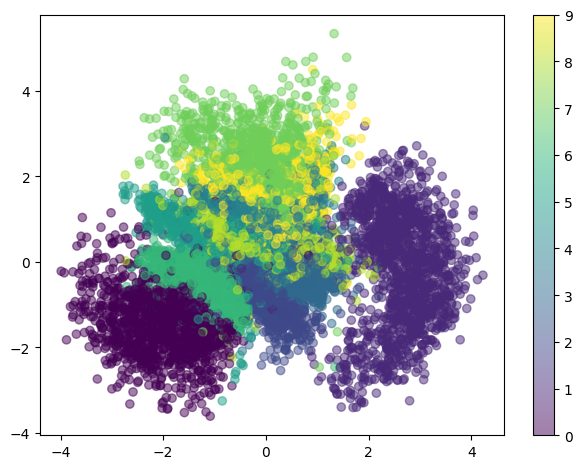

In [10]:
# Plot Latent space
plot_latent(data_loader_vae, trained_model)
plt.tight_layout()
wandb.log({"latent_space": wandb.Image(plt.gcf())})
plt.show()


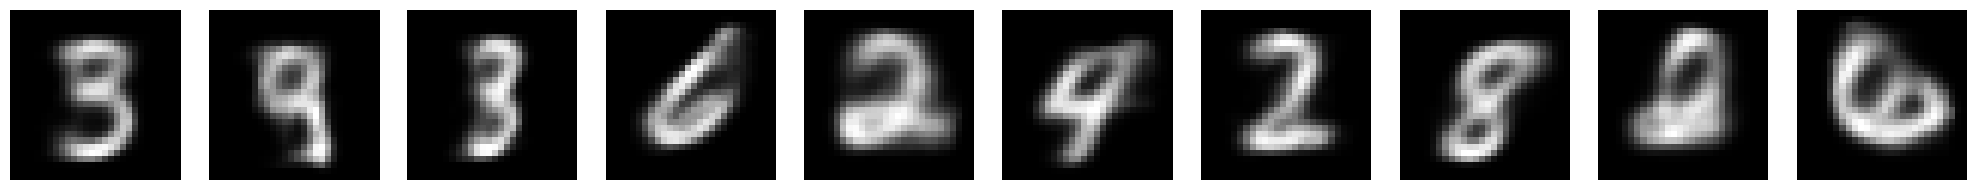

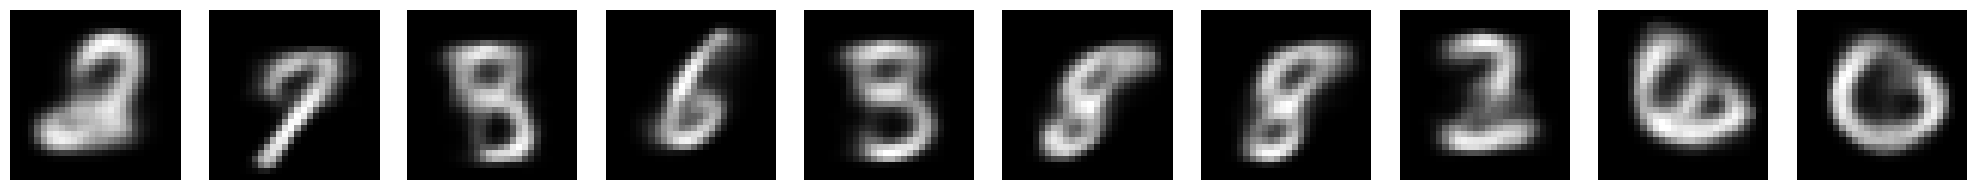

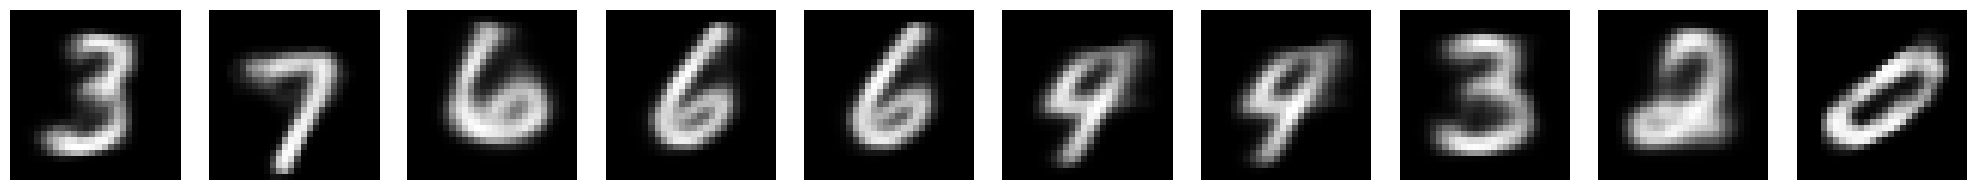

In [11]:
def plot_generated_samples(model, num_samples=10):
    with torch.no_grad():
        z = torch.randn(num_samples, model.fc21.out_features).to(device)
        generated = model.decode(z).cpu().view(-1, 28, 28).numpy()

    fig, axs = plt.subplots(1, num_samples, figsize=(20, 2))
    for i, img in enumerate(generated):
        axs[i].imshow(img, cmap="gray")
        axs[i].axis("off")
    return fig


# Plot generated samples
for t in range(3):
    fig = plot_generated_samples(trained_model)
    fig.tight_layout()
    fig.savefig(f"generated_run_{t+1}.pdf")
    wandb.log({
        f"generated_samples_run_{t+1}": wandb.Image(fig)
    })

    plt.show()
    plt.close(fig) 

In [12]:
wandb.finish()

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
epoch_end,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
loss_bce,█▆▆▅▅▅▆▄▃▂▄▄▄▃▄▃▃▂▂▂▅▄▃▁▂▁▂▁▃▂▁▃▂▃▂▂▁▁▁▁
loss_kld,▂▁▄▃▄▄▅▆▆▅▆▅▅▆▄▅▆▆▅▆▆▆▇▅▆▇▆█▅▇█▇█▇▆▇██▇▇
loss_total,█▆▅▄▄▂▄▂▂▂▃▃▃▄▃▂▂▂▃▁▃▂▂▃▃▂▂▃▂▃▂▂▂▂▂▃▁▂▂▁
step,▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch,19
epoch_end,19
loss_bce,18614.83984
loss_kld,781.2395
loss_total,19396.08008


## **Answers to questions 2.5**
The notebook `vae.ipynb` follows the same overall workflow as the earlier autoencoder experiments, but extends the model to a probabilistic latent-variable setting. It begins by importing the required PyTorch modules for neural networks, optimization, data handling, and visualization, and then selects the computation device to ensure consistent execution across CPU and GPU.

### Functions
The core model is defined in the `VAE` class, which replaces the deterministic encoder with a stochastic encoder. The encoder maps each flattened MNIST image through a hidden layer and outputs two vectors: the mean $\mu$ and the log-variance $\log \sigma^2$ of a Gaussian latent distribution. The `reparameterize` function implements the reparameterization trick by sampling a latent vector as

$$
z = \mu + \varepsilon\,\sigma,
\qquad \varepsilon \sim \mathcal{N}(0, I),
\qquad \sigma = \exp\!\left(\tfrac{1}{2}\log\sigma^2\right),
$$

allowing gradients to propagate through the sampling step. The decoder then maps the sampled latent vector back to the data space using a hidden layer and a Sigmoid output activation to reconstruct the image. The `train` function performs the training loop by iterating over epochs and mini-batches, computing the loss, backpropagating gradients, and updating model parameters. Additional helper functions visualize the latent space and generate new samples from the model.

### Transform
The data preprocessing pipeline converts MNIST images to tensors and flattens each $28 \times 28$ image into a 784-dimensional vector so it can be processed by the fully connected network. Pixel values remain scaled to the interval $[0,1]$, which is consistent with the Sigmoid output of the decoder and the reconstruction loss used during training.

### Model Definition
The variational autoencoder consists of an encoder, a latent sampling step, and a decoder. Unlike the standard autoencoder, the encoder does not output a single latent code but instead parameterizes a distribution over latent variables. During training, latent vectors are sampled from this learned distribution, while during generation, latent vectors are sampled from a standard normal prior. This probabilistic formulation enforces structure in the latent space and enables meaningful sampling of new data points.

### Loss Function
The training objective combines a reconstruction term and a regularization term. In the slides, this objective is derived from the Evidence Lower Bound (ELBO),

$$
\log p_\theta(x)
\;\ge\;
\mathcal{L}_{\theta,\phi}(x)
=
\mathbb{E}_{q_\phi(z \mid x)}\!\left[\log p_\theta(x \mid z)\right]
-
\mathrm{KL}\!\left(q_\phi(z \mid x)\,\|\,p(z)\right).
$$

The reconstruction loss is implemented as binary cross-entropy between the input image and its reconstruction, measuring how accurately the decoder reproduces the data. The KL divergence term penalizes deviations between the learned latent distribution and a standard normal prior, encouraging a smooth and continuous latent space. The loss minimized during training corresponds to the negative ELBO,

$$
\mathcal{L}
=
\mathrm{BCE}(x, \hat{x})
+
\mathrm{KL}\!\left(q(z \mid x)\,\|\,p(z)\right),
$$

and the implementation in the notebook directly reflects this formulation by summing the reconstruction loss and the KL divergence term during training.
